# Assignment 3: Linear Models

In [1]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()


Download complete
Extracting data files...
Data extracted


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is considered linear in the context of machine learning when an addition of coefficients is applied to variables. When coefficients (or weights if you will) are multiplied or applied to a variable usually representing a specific dimension of a property, this linear combination of simply coefficients and variables constitute a linear model and a linear prediction. It is linear in how the coefficients are entered into the arithmitic of the model, which is commonly through mulitiplication followed by addition.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

In a dummy/one-hot-encoded variable, the intercept of the model represents the reference or the category that simply got dropped during the process to prevent linear dependency between columns. This coefficient that represents the intercept ends up becoming the predicted value for the reference category that got dropped. The coefficient for a variable ends up representing then the pure difference between the reference and the coefficient of interest assuming the other aspects are kept constant.

3. Can linear regression be used for classification? Explain why, or why not.

In theory if you assign boundary points or intervals corresponding to certain classes it may be possible. However, this is generally not the most effective method as linear regression inherently is great for computing a more quantative output or a numerical value rather than a class. Therefore, in theory a linear regression might be able to be used for classification in directly but this is not what it is best at.

4. What are signs that your linear model is over-fitting?

A clear sign would be if the linear model is able to produce very little data on the training data set but is unable to give accurate results in unseen or test data, indicating that it was overfit to the training data too closely. Properties such as multicollinearity and too many variables that are creating hyper specific predictions can contribute to this issue, and in some cases, reducing variabels and therefore noise can improve the generalizability of the model itself. Ultimately, if the model has a huge discrepency between the training accuracy and the test accuracy, there is likely some overfitting going on.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multi-colinearity is essentially when more than one variable attempts to explain the same change in the outcome when they impact the outcome in a similar fashion. Using the two-stage least squares technique, if you regress y and your variable of interest say x on the other variables, you get two residuals. One is the residual of y on the other variables and one is the residual of x on the other variables. If you then regress the residual of y onto the residual of x you end up getting the slope coefficient defining this relationship. However, if the residual of x is tiny because x is giving too similar of an effect to the other variables as is the case in multi-colineraity, the residual slope coefficient becomes highly unstable and unreliable in the actual model itself.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

It is possible to attempt to capture nonlinear relationships between the variables and outcomes while keeping the model linear in this analysis because linearity here in this context depends on the linearity of the coefficients. It is possible to incorporate polynomial features for example like powers to the variables as long as the general format of coefficients or weighing multiplying into a "variable" is preserved. Variables can also outright interact with each other in some cases like multiplication as long as the coefficient is kept linear, and variable transformations in non-linear ways is possible such as a log. But the important aspect that must be consistent though in order to remain a linear model is the linearity of the coefficients, and the general structure of how the prediction is made should not change. This was explained in the first question.

7. What is the interpretation of the slope coefficient in a linear regression?

Essentially the change in the outcome for a 1 unit change in the variable the slope coefficient pertains to, possibly assuming all other terms in the equation are kept constant if there are many variables.

8. Compare the train/test split and $k$-fold cross validation.

A train/test split relies on quite simply splitting the data into a training data set and a test data set. This is pretty conventional and relies on having the model train itself on the training data and then being tested on the other part of the data. A k-fold cross validation however splits the data into "k" groups, and these various splits of the data are each used as the testing data once while the rest of the data is used as the training data, giving a multitude of values that can be averaged to get average performance.

9. How is the $k$ in $k$-fold cross validation typically selected?

A conventional value used by many data scientists tends to be 10, however this optimized value can in theory be found with empirical testing with performance. It is also worthwhile for the data scientist to consider certain factors such as computational limitations that may follow with using larger values of k. The balance in variance and bias is also something that might be considered as a trade off between higher and lower k values. Overall, a k value of 10 is a good standard value but certain factors such as computational cost, bias, and variance might also be considered by the model designer.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.

On average, Manhatten is the most expensive neighborhood. The kernel density plot of price and log price also support this assertion.

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

It appears that the coefficients in the regression is simply the difference between that neighborhood's mean and the baseline mean or the mean of the category that was dropped and became the intercept (which was the Bronx in this case). The conditional group means therefore are essentially the intercept added to the estimated coefficients.

3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

The slope coefficient essentially means that for every one unit increase in the review scores rating, we expect the slope coefficient worth of change. In this case, about 1.02 or so.

4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?

The slope coefficient on Review Scores Rating increased slightly. The neighborhood averages or the coefficients did change slightly and they either increased or decreased, resulting from the model having to condition the review score dimension. This means that the same logic with the conditional mean simply being the addition of the intercept and the coefficient does not apply anymore here at least mathematically. In other words, we get conditioned averages adjusting for another variable now, which changes its representation.

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?

The slopes are "similar" in the sense they are within a few integers of magnitude but realistically they should not be considered similar. The impact of Review Scores Rating is disproportionate and some are more than triple others.

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

Done.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Q1_clean.csv to Q1_clean.csv


In [3]:
import pandas as pd

df = pd.read_csv("Q1_clean.csv")
print(df.head())

   Price  Review Scores Rating Neighbourhood  Property Type        Room Type
0    549                  96.0      Manhattan     Apartment     Private room
1    149                 100.0       Brooklyn     Apartment  Entire home/apt
2    250                 100.0      Manhattan     Apartment  Entire home/apt
3     90                  94.0       Brooklyn     Apartment     Private room
4    270                  90.0      Manhattan     Apartment  Entire home/apt


                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.843750


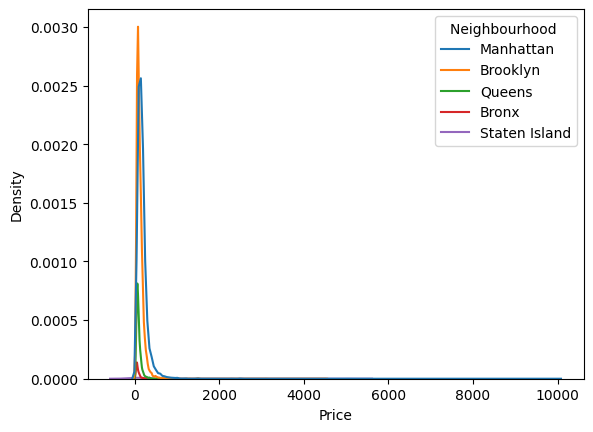

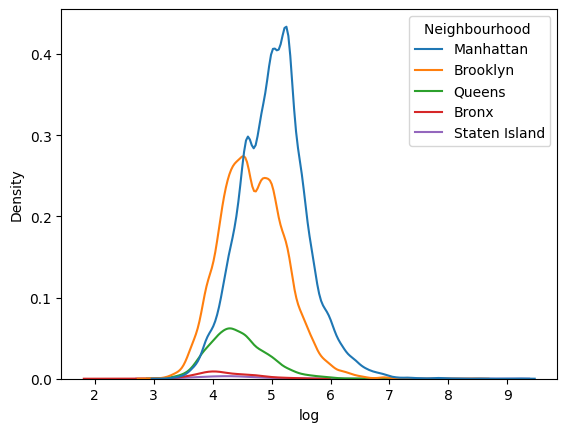

Model intercept: 75.27649769585331


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


In [19]:
print(df.groupby("Neighbourhood ")[["Price","Review Scores Rating"]].mean())

import numpy as np

df["log"] = np.log(df["Price"])

import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df, x="Price", hue="Neighbourhood ")
plt.show()

sns.kdeplot(data=df, x="log", hue="Neighbourhood ")
plt.show()

from sklearn.linear_model import LinearRegression
tdf = df.loc[:, ["Price", "Neighbourhood "]].dropna()

y = tdf["Price"]

X = pd.get_dummies(tdf["Neighbourhood "], drop_first=True)

model = LinearRegression()
model = model.fit(X, y)

print(f"Model intercept: {model.intercept_}")
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })


In [30]:
tdf = df.loc[:, ["Price", "Review Scores Rating"]].dropna()

y = tdf["Price"]

X = tdf[["Review Scores Rating"]]

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores = []
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    score = mean_squared_error(y_test, y_hat)
    scores.append(score)

print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))

Model intercept: 60.878390657123546
Fold scores: [21829.763593759206, 19868.98360556362, 11817.156441453972, 16312.13636088279, 64942.14736037084, 26322.78394158244, 10503.266954428698, 17837.67903474583, 18706.609784105083, 12671.215751504998]
Mean score: 22081.174282839747
Median score: 18272.144409425455
Std dev: 15002.110906515418


In [31]:
tdf = df.loc[:, ["Price", "Neighbourhood ", "Review Scores Rating"]].dropna()
y = tdf["Price"]

Xn = pd.get_dummies(tdf["Neighbourhood "], drop_first=True)

X = pd.concat([Xn, tdf[["Review Scores Rating"]]], axis = 1)

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores = []
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    score = mean_squared_error(y_test, y_hat)
    scores.append(score)

print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))

Model intercept: -23.812561011672244
Fold scores: [21072.73152241064, 18687.57661921651, 10882.496868536404, 15248.277420451173, 63708.24722133323, 25072.368099350344, 9453.163201888718, 16775.185243174004, 17872.771087624722, 11935.282939931596]
Mean score: 21070.810022391735
Median score: 17323.978165399363
Std dev: 14914.60476143176


In [32]:
tdf = df.loc[:, ["Price", "Neighbourhood ", "Review Scores Rating"]].dropna()
y = tdf["Price"]

X = pd.get_dummies(tdf["Neighbourhood "], drop_first=False)

Xfinal = X.multiply(tdf["Review Scores Rating"], axis=0)

model = LinearRegression()
model = model.fit(Xfinal, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores = []
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    score = mean_squared_error(y_test, y_hat)
    scores.append(score)

print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))

Model intercept: 55.11825364116355
Fold scores: [20844.265171047173, 18860.16275506415, 10953.860960225586, 15390.032087095771, 63897.47346724899, 25093.281734416294, 9520.191373019696, 16890.745381230856, 18034.147802040465, 12065.919898652717]
Mean score: 21155.00806300417
Median score: 17462.44659163566
Std dev: 14936.511516241435


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?

  The SUV seems to have the highest standard deviation and the highest mean, indicating that the SUV car type might be the most expensive overall and on average while having the highest variance.

  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

  The slope coefficient is about 59268 or so. For every one unit increase in seating capacity, the slope coefficient represents the amount the price will change by. The differences in price does not seem roughly linear in the number of seats based on the one hot encoded variable version because the difference or increase/decrease in price between each column representing an incremental increase in the seating capacity is not consistent and in fact fluctuates between a positve or negative change.

  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.

  Based on the method I attempted I got a value of 7 measuring a reasonable range of 1 to 10 in terms of possible powers.

  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

  The model covers the general trends in the data and you could say qualitatively it is of acceptable form compared to the data. However, the data in general seems to be all over the place in the scatter plot so a clean linear outline is not very possible. Given this consideration, I would say that the model can reasonably predict the data as it does indeed seem to be around the middle of each gradient of values in each x axis tick line.


In [42]:
import pandas as pd

df = pd.read_csv("/content/data/cars_hw.csv")
print(df.head())

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


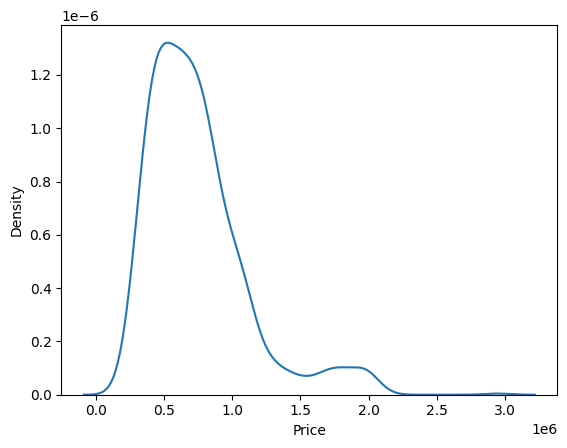

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


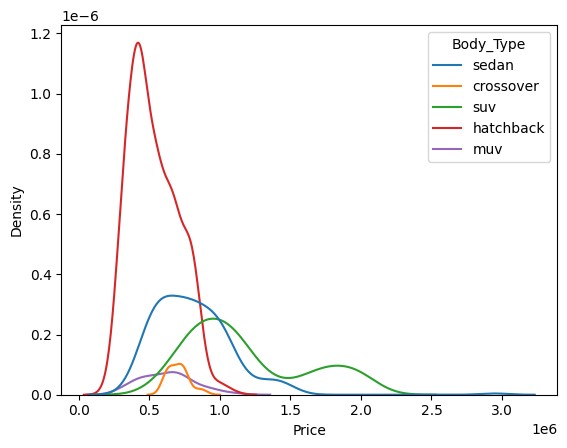

In [43]:
print(df["Price"].describe())

sns.kdeplot(data=df, x="Price")
plt.show()

print(df.groupby("Body_Type")["Price"].describe())

sns.kdeplot(data=df, x="Price", hue="Body_Type")
plt.show()

In [47]:
from sklearn.linear_model import LinearRegression
import pandas as pd

tdf = df.loc[:, ["Price", "Seating_Capacity"]].dropna()
y = tdf["Price"]
X = tdf[["Seating_Capacity"]]

model = LinearRegression()
model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 439032.0141018266


,variable,coefficient
0,Seating_Capacity,59267.998037


In [49]:
X = pd.get_dummies(tdf["Seating_Capacity"], drop_first=True)

model = LinearRegression()
model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':X.columns, 'coefficient':model.coef_ })

Model intercept: 188000.00000000314


,variable,coefficient
0,5,5.464839e+05
1,6,1.456000e+06
2,7,7.359487e+05
3,8,2.718000e+05


In [57]:
now = 2026
df["Age"] = now - df["Make_Year"]

tdf = df[["Price", "Age"]].dropna()
y = tdf["Price"]
X = tdf[["Age"]]

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

score = make_scorer(mean_squared_error, greater_is_better=False)

limit = 10
outcome = []

for power in range(1, limit):
    X_mod = pd.concat([X["Age"]**d for d in range(1, power+1)], axis=1)
    X_mod.columns = [f"Age^{d}" for d in range(1, power+1)]

    model = LinearRegression()
    scores = cross_val_score(model, X_mod, y, cv=kf, scoring=score)

    final = -scores
    outcome.append({
        "power": power,
        "fold_scores": final,
        "performance": np.mean(final)
    })

print(outcome)

print(min(outcome, key=lambda r: r["performance"])["power"])

[{'power': 1, 'fold_scores': array([7.01095245e+10, 9.57383807e+10, 1.00947654e+11, 1.42290185e+11,
       9.94792040e+10, 1.02476852e+11, 7.69999389e+10, 1.00640658e+11,
       8.83508030e+10, 9.67392807e+10]), 'performance': np.float64(97377248063.9968)}, {'power': 2, 'fold_scores': array([6.98177664e+10, 9.59135436e+10, 1.01074720e+11, 1.42809685e+11,
       9.91313181e+10, 1.02213425e+11, 7.70819499e+10, 1.00380143e+11,
       8.87985843e+10, 9.67359246e+10]), 'performance': np.float64(97395705968.63509)}, {'power': 3, 'fold_scores': array([6.96032356e+10, 9.58511133e+10, 1.01153252e+11, 1.42417236e+11,
       9.72167777e+10, 1.01938301e+11, 7.53891985e+10, 9.97997045e+10,
       8.77129187e+10, 9.63503109e+10]), 'performance': np.float64(96743204818.44339)}, {'power': 4, 'fold_scores': array([7.11853171e+10, 9.54645527e+10, 1.00791806e+11, 1.41178249e+11,
       9.46248544e+10, 1.03936580e+11, 7.32205098e+10, 9.94495003e+10,
       8.63312442e+10, 9.60677687e+10]), 'performance': 

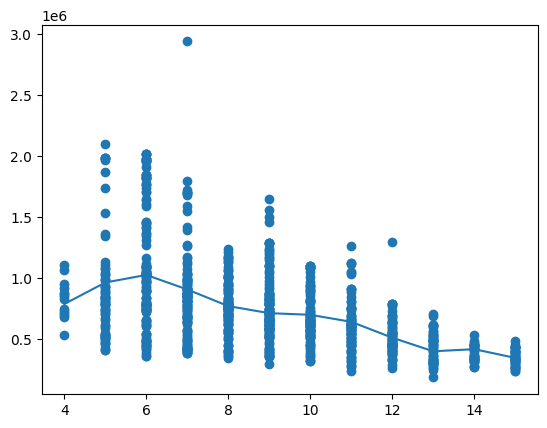

In [72]:
import matplotlib.pyplot as plt

x = df["Age"].values
y = df["Price"].values

from sklearn.linear_model import LinearRegression

x = x.reshape(-1, 1)

power = 7
X = pd.concat([df["Age"]**d for d in range(1, power+1)], axis=1)
X.columns = [f"Age^{d}" for d in range(1, power+1)]

model = LinearRegression()
model.fit(X, y)
Y = model.predict(X)

sort = np.argsort(x.flatten())
xs = x[sort]
Ys = Y[sort]

plt.scatter(x, y)
plt.plot(xs, Ys)

plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

I got 0.2302 or so.

2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

The intercept and the translplant coefficient added together looks like the proportion of people who survived with the transplant.

3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age? What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

Both the model intercept and the slope coefficient for transplant increased and changed by controlling for age. The intercept is the predicted survival for 3 years for the mathematical reference age or control such as 0. The slopes for both represents the change in survival probability per 1 unit change in age or the change in survival probability by the transplant with other factors held constant. It looks like the ATE under-estimates for ages around 55 and less and over-estimates for ages above 55.

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?

The coefficient slope for transplant seems to have increased again. Allowing age and transplant to interact actually makes the threshold age for where the ATE underestimates or overestimates change. Now, the intersection between the model's prediction and the ATE is occuring at a lower age, around 50 or the early 50s, rather than at around 55.

5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.

Done below.

6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

A critical concern is whether this model actually takes into consideration an appropriate number of variables. Clearly adding age as a factor can change the prioritization based on age, but there are way more factors at play here such as certain activites, genetics, and even demographic details. How can we be sure that the model as it stands is taking enough factors into consideration while also having the perfect amount to not be overwhelemed by noise? The size of the data also seems to be quite small so there would be need to be significantly more credible data if we are to deploy this into the field of medicine. There is also a principle ethical concern. How much error % do we even consider reasonable here? If a model, say relatively gets priorities 5% wrong, is that even ethical? During construction, controlling for variables to actually have a credible performance will be an issue as it certainly changes the model, and at the deployment phase, there will be issues in regards to ethics and safety.


In [73]:
from google.colab import files
uploaded = files.upload()

Saving heart_hw.csv to heart_hw.csv


In [76]:
import pandas as pd

df = pd.read_csv("heart_hw.csv")
print(df.head())

survivecontrol = df[df["transplant"] == "control"]["y"].mean()
print(survivecontrol)

treatsurvive = df[df["transplant"] == "treatment"]["y"].mean()
print(treatsurvive)

ate = treatsurvive - survivecontrol
print(ate)

   Unnamed: 0  age transplant  y
0           1   53    control  0
1           2   43    control  0
2           3   52    control  0
3           4   52    control  0
4           5   54    control  0
0.11764705882352941
0.34782608695652173
0.23017902813299232


In [91]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df["dummy"] = (df["transplant"] == "treatment")

y = df["y"]
X = df[["dummy"]]

model = LinearRegression()
model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores = []
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    score = mean_squared_error(y_test, y_hat)
    scores.append(score)

print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))

Model intercept: 0.1176470588235293
Fold scores: [0.18488636363636363, 0.2017158052954099, 0.2470096180493702, 0.1737777777777778, 0.240946785475405, 0.1773613130295036, 0.2268283055630207, 0.2268283055630207, 0.10988553590010405, 0.14144803144316048]
Mean score: 0.1930687841733136
Median score: 0.19330108446588676
Std dev: 0.04222093390745557


Model intercept: 0.7019569721740947
  variable  coefficient
0    dummy     0.264702
1      age    -0.013607


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


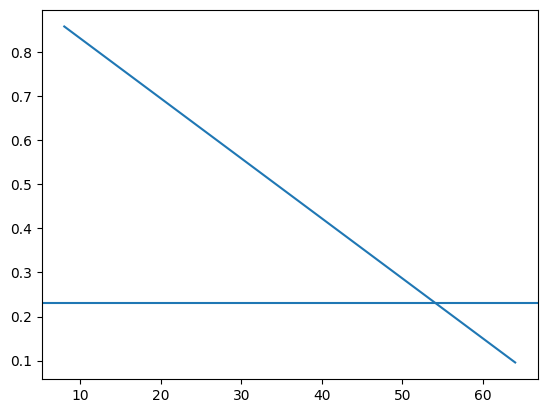

Fold scores: [0.16190327904937485, 0.18388446116172846, 0.21324552222928733, 0.156839121259134, 0.19829743628562252, 0.25082454078821553, 0.22393301156494072, 0.18486278358933364, 0.08362355276636343, 0.11525145716107758]
Mean score: 0.1772665165855078
Median score: 0.18437362237553107
Std dev: 0.04763928356649321


In [92]:
y = df["y"]
X = df[["dummy", "age"]]

model = LinearRegression()
model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
print(pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ }))

age_range = np.linspace(df["age"].min(), df["age"].max(), 100)

Xtreat = np.column_stack([np.ones(100), age_range])
predic = model.predict(Xtreat)

plt.plot(age_range, predic)
plt.axhline(y=ate)

plt.show()

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores = []
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    score = mean_squared_error(y_test, y_hat)
    scores.append(score)

print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))


Model intercept: 0.35486517529945855
  variable  coefficient
0    dummy     0.907751
1      age    -0.005524
2       ta    -0.014591


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


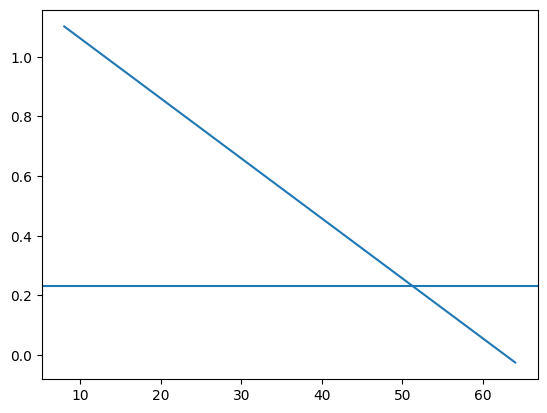

Fold scores: [0.1587450904906421, 0.1821759722659768, 0.23087008535221365, 0.14503339901757734, 0.19474557504204254, 0.21898896182304056, 0.26511598770056755, 0.1720534538957827, 0.07792587213483693, 0.10554982447628544]
Mean score: 0.17512042221989654
Median score: 0.17711471308087973
Std dev: 0.05388528399106028


In [93]:
df["ta"] = df["dummy"] * df["age"]

y = df["y"]
X = df[["dummy", "age", "ta"]]

model = LinearRegression()
model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
print(pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ }))

age_range = np.linspace(df["age"].min(), df["age"].max(), 100)

Xtreat = np.column_stack([np.ones(100), age_range, age_range])
predic = model.predict(Xtreat)

plt.plot(age_range, predic)
plt.axhline(y=ate)

plt.show()

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores = []
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    score = mean_squared_error(y_test, y_hat)
    scores.append(score)

print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))

